In [1]:
import numpy as np
import random
import pandas as pd 
import os
import re
from typing import Optional, Dict, Any, Tuple, List
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import optuna
import warnings
import polars as pl
import time
import math
import gc
import lightgbm as lgb
from scipy.stats import spearmanr
import joblib
import kaggle_evaluation.default_inference_server
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="lightgbm")
from IPython.display import display, Markdown
from scipy.stats import spearmanr
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/hull-tactical-market-prediction/train.csv
/kaggle/input/hull-tactical-market-prediction/test.csv
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/default_inference_server.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/default_gateway.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/__init__.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/templates.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/base_gateway.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/relay.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/kaggle_evaluation.proto
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/__init__.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/generated/kaggle_evaluation_pb2.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/generated/kaggle_evaluation_pb2_grpc.py
/kaggl

In [2]:
train_df = pd.read_csv('/kaggle/input/hull-tactical-market-prediction/train.csv')
test_df =pd.read_csv('/kaggle/input/hull-tactical-market-prediction/test.csv')

train_df.head(5)

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,I8,I9,M1,M10,M11,M12,M13,M14,M15,M16,M17,M18,M2,M3,M4,M5,M6,M7,M8,M9,P1,P10,P11,P12,P13,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
0,0,0,0,0,1,1,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002421,0.000301,-0.003038
1,1,0,0,0,1,1,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008495,0.000303,-0.009114
2,2,0,0,0,1,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009624,0.000301,-0.010243
3,3,0,0,0,1,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004662,0.000299,0.004046
4,4,0,0,0,1,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.011686,0.000299,-0.012301


# Features Engineering¶
* Create lag featires, rolling window features, percentage change features (Volatility)
* Handle missing values: Forward filling → Backward filling → Median filling

In [3]:
# Lag Features
def add_lag_features(df: pd.DataFrame, cols, lags):
    for col in cols:
        if col not in df.columns:
            continue
        for lag in lags:
            df[f"{col}_lag_{lag}"] = df[col].shift(lag)
    return df

# Rolling Window Features
def add_rolling_features(df: pd.DataFrame, cols, windows):
    for col in cols:
        if col not in df.columns:
            continue
        for w in windows:
            df[f"{col}_roll_mean_{w}"] = df[col].rolling(w, min_periods=1).mean()
            df[f"{col}_roll_std_{w}"] = df[col].rolling(w, min_periods=1).std()
            df[f"{col}_roll_min_{w}"] = df[col].rolling(w, min_periods=1).min()
            df[f"{col}_roll_max_{w}"] = df[col].rolling(w, min_periods=1).max()
            df[f"{col}_roll_median_{w}"] = df[col].rolling(w, min_periods=1).median()
    return df

# Percentage Change Features (Volatility / Momentum)
def add_pct_change_features(df: pd.DataFrame, cols, periods=[1, 3, 7]):
    for col in cols:
        if col not in df.columns:
            continue
        for p in periods:
            df[f"{col}_pct_change_{p}"] = df[col].pct_change(periods=p)
    return df

# First Difference
def add_diff_features(df: pd.DataFrame, cols):
    for col in cols:
        if col in df.columns:
            df[f"{col}_diff_1"] = df[col].diff(1)
            df[f"{col}_diff_7"] = df[col].diff(7)
    return df

# Exponential Weighted Moving Features
def add_ewm_features(df: pd.DataFrame, cols, spans=[7, 14, 30]):
    for col in cols:
        if col not in df.columns:
            continue
        for s in spans:
            df[f"{col}_ewm_mean_{s}"] = df[col].ewm(span=s, adjust=False).mean()
            df[f"{col}_ewm_std_{s}"] = df[col].ewm(span=s, adjust=False).std()
    return df

# Feature Interactions (non-linear relationships)
def add_interaction_features(df: pd.DataFrame, cols):
    numeric_cols = [c for c in cols if df[c].dtype != "object"]
    
    for i, c1 in enumerate(numeric_cols):
        for c2 in numeric_cols[i+1:]:
            df[f"{c1}_x_{c2}"] = df[c1] * df[c2]
            df[f"{c1}_div_{c2}"] = df[c1] / (df[c2] + 1e-7)
    return df

# Rolling Normalization (z-score inside windows)
def add_rolling_normalized_features(df: pd.DataFrame, cols, windows=[14, 30]):
    for col in cols:
        if col not in df.columns:
            continue
        
        for w in windows:
            m = df[col].rolling(w, min_periods=1).mean()
            s = df[col].rolling(w, min_periods=1).std()
            df[f"{col}_roll_zscore_{w}"] = (df[col] - m) / (s + 1e-7)
    return df

# Feature create pipeline
def create_features(df: pd.DataFrame) -> pd.DataFrame:

    """
    Feature engineering pipeline:
    1. Use the columns in TOP_FEATURES_FOR_FE as the base features.
    2. Apply all feature engineering functions in sequence.
    3. Handle missing values: Forward filling → Backward filling → Median filling 
    Note: Define TOP_FEATURES_FOR_FE, LAG_PERIODS, and ROLLING_WINDOWS in advance. 
    """
    
    # Define primary columns for FE
    cols = TOP_FEATURES_FOR_FE
    
    # --- Base FE ---
    df = add_lag_features(df, cols, LAG_PERIODS)
    df = add_rolling_features(df, cols, ROLLING_WINDOWS)

    # --- Extra FE modules ---
    df = add_pct_change_features(df, cols)
    df = add_diff_features(df, cols)
    df = add_ewm_features(df, cols)
    df = add_interaction_features(df, cols)
    df = add_rolling_normalized_features(df, cols)

    df.ffill(inplace=True)
    df.bfill(inplace=True)
    
    for c in df.columns:
        if df[c].isnull().any():
            df[c].fillna(df[c].median(), inplace=True)

    return df

# Data Analysis¶
* missing rate
* correlation
* outliers

In [4]:
def describe_dataset(df: pd.DataFrame):
    """
    Overview of a DataFrame, including dimensions, memory usage.
    """
    
    display(Markdown("## Dataset Overview"))
    
    # shape
    num_rows, num_cols = df.shape
    print(f"Shape (Rows, Columns): ({num_rows:,}, {num_cols:,})")
    
    # memory
    mem_usage = df.memory_usage(deep=True).sum()
    mem_gbs = mem_usage / (1024**2)
    print(f"Total Memory Usage: {mem_gbs:.2f} MB")

def missing_rate_analysis(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    # missing summary
    missing_counts = df.isnull().sum()
    missing_summary = pd.DataFrame({
        'Missing_Count': missing_counts,
        'Missing_Percent': 100 * missing_counts / len(df)
    })
    missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]
    missing_summary = missing_summary.sort_values(by='Missing_Count', ascending=False)
    
    
    # check for duplicates
    num_duplicates = df.duplicated().sum()
    print(f"Duplicate rows found: {df.duplicated().sum()}")
    
    # visualisation
    if missing_summary.empty:
        print("No missing values found in the dataset.")
        return pd.DataFrame()
    
    print(f"\nTotal features with missing values: {len(missing_summary)}")
    
    # Select the top n features
    plot_data = missing_summary.head(top_n)
    
    plt.style.use('ggplot')
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=plot_data.index,
        y='Missing_Count',
        data=plot_data,
        palette='viridis'
    )
    
    # Add percentage labels above the bars
    for i, count in enumerate(plot_data['Missing_Count']):
        percent = plot_data['Missing_Percent'].iloc[i]
        plt.text(
            x=i, 
            y=count + (df.shape[0] * 0.005),
            s=f'{percent:.1f}%',
            ha='center',
            fontsize=9
        )
    
    plt.title(f"Top {min(top_n, len(missing_summary))} Features by Missing Values Count (Total Rows: {len(df)})", 
              fontsize=14, fontweight='bold')
    plt.xlabel("Feature Name", fontsize=12)
    plt.ylabel("Missing Count", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    print("\nMissing Data Summary Table (Missing rate > 30%):")
    print(missing_summary.head(12).to_markdown(floatfmt=".2f"))
    return missing_summary


def detect_outliers(df, method='iqr', threshold=2.5, z_threshold=3.0, cols=None, summary=True):

    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if method not in ['iqr', 'zscore']:
        raise ValueError("method must be 'iqr' or 'zscore'")

    outlier_flags = pd.DataFrame(False, index=df.index, columns=cols)

    for col in cols:
        series = df[col].dropna()

        if method == 'iqr':
            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR
            outlier_flags[col] = (df[col] < lower_bound) | (df[col] > upper_bound)

        elif method == 'zscore':
            z_scores = np.abs(stats.zscore(series))
            outlier_flags[col] = z_scores > z_threshold

    if summary:
        summary_df = pd.DataFrame({
            'outlier_count': outlier_flags.sum(),
            'percent_outliers': 100 * outlier_flags.sum() / len(df)
        }).sort_values('percent_outliers', ascending=False)

        print("Outlier Detection Summary (Top 50):")
        print(summary_df.round(2).head(50))
        return outlier_flags, summary_df

    return outlier_flags

def correlation(df: pd.DataFrame):
    df = df.iloc[1006:].reset_index(drop=True)
    df = df.ffill().bfill()
    
    feature_groups = ["D","E","I","M","P","S","V"] 
    cols = []
    for g in feature_groups:
        group_cols = [c for c in df.columns if re.match(rf"^{g}\d+$", c)]
        # Natural Sort: Sort by the size of the numbers, ensuring D1, D2,... The sequence of D10
        group_cols = sorted(group_cols,key=lambda x: (re.match(r"^([A-Z]+)(\d+)$", x).group(1),
                           int(re.match(r"^([A-Z]+)(\d+)$", x).group(2))))
        cols += group_cols
    target_cols = ["forward_returns", "risk_free_rate", "market_forward_excess_returns"]
    cols = cols + target_cols
    corr = df[cols].corr(method="pearson")
    
    sns.set(style="whitegrid", font_scale=0.9)
    n = len(cols)
    fig_size = (max(10, 0.38 * n), max(10, 0.38 * n))
    fig, ax = plt.subplots(figsize=fig_size)
    # Only display the lower triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Color matching: Red is positively correlated, and blue is negatively correlated
    cmap = sns.diverging_palette(240, 10, as_cmap=True)

    hm = sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f",
    annot_kws={"size": 7},
    square=True,
    linewidths=0.6,
    linecolor="#dddddd",
    cbar_kws={"shrink": 0.6, "label": ""},
    ax=ax
)

    ax.set_title("Feature Correlation Matrix", fontsize=14, pad=12)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()


In [5]:
describe_dataset(train_df)

## Dataset Overview

Shape (Rows, Columns): (9,021, 98)
Total Memory Usage: 6.74 MB


Duplicate rows found: 0

Total features with missing values: 85


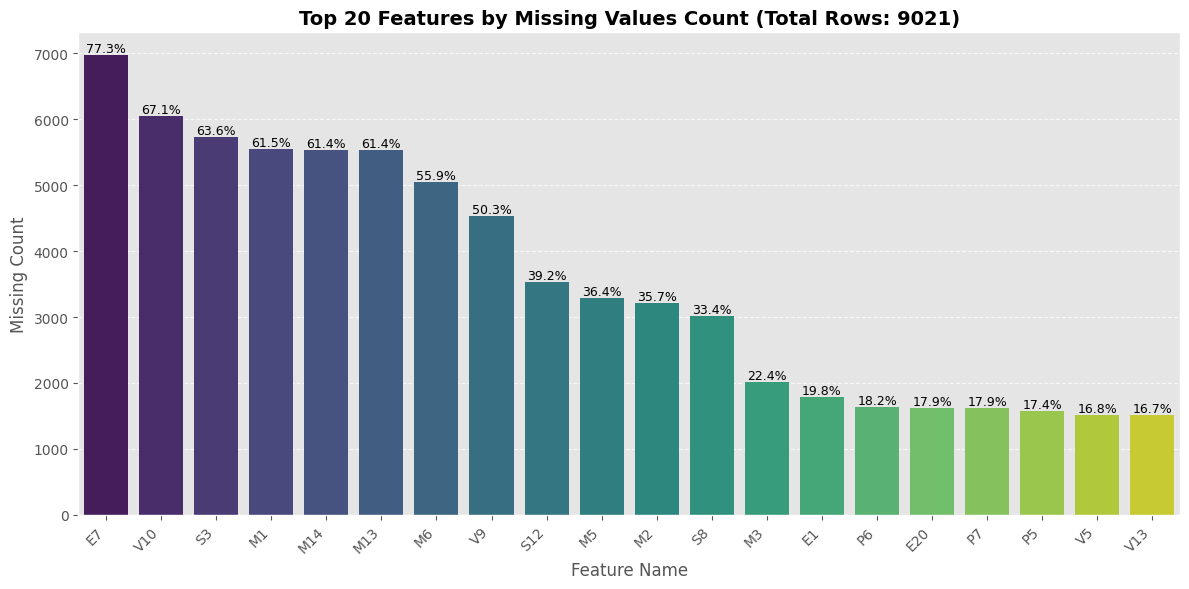


Missing Data Summary Table (Missing rate > 30%):
|     |   Missing_Count |   Missing_Percent |
|:----|----------------:|------------------:|
| E7  |         6969.00 |             77.25 |
| V10 |         6049.00 |             67.05 |
| S3  |         5733.00 |             63.55 |
| M1  |         5547.00 |             61.49 |
| M14 |         5540.00 |             61.41 |
| M13 |         5540.00 |             61.41 |
| M6  |         5043.00 |             55.90 |
| V9  |         4539.00 |             50.32 |
| S12 |         3537.00 |             39.21 |
| M5  |         3283.00 |             36.39 |
| M2  |         3217.00 |             35.66 |
| S8  |         3009.00 |             33.36 |


In [6]:
missing_df_summary = missing_rate_analysis(train_df)

In [7]:
outliers, summary = detect_outliers(train_df, method='iqr')

Outlier Detection Summary (Top 50):
                               outlier_count  percent_outliers
D6                                      2148             23.81
D5                                      1718             19.04
E4                                      1396             15.48
D9                                      1290             14.30
D8                                      1287             14.27
E12                                     1129             12.52
E11                                     1032             11.44
E6                                       992             11.00
E14                                      632              7.01
P6                                       553              6.13
S5                                       498              5.52
D3                                       431              4.78
E13                                      414              4.59
D7                                       412              4.57
D2                 

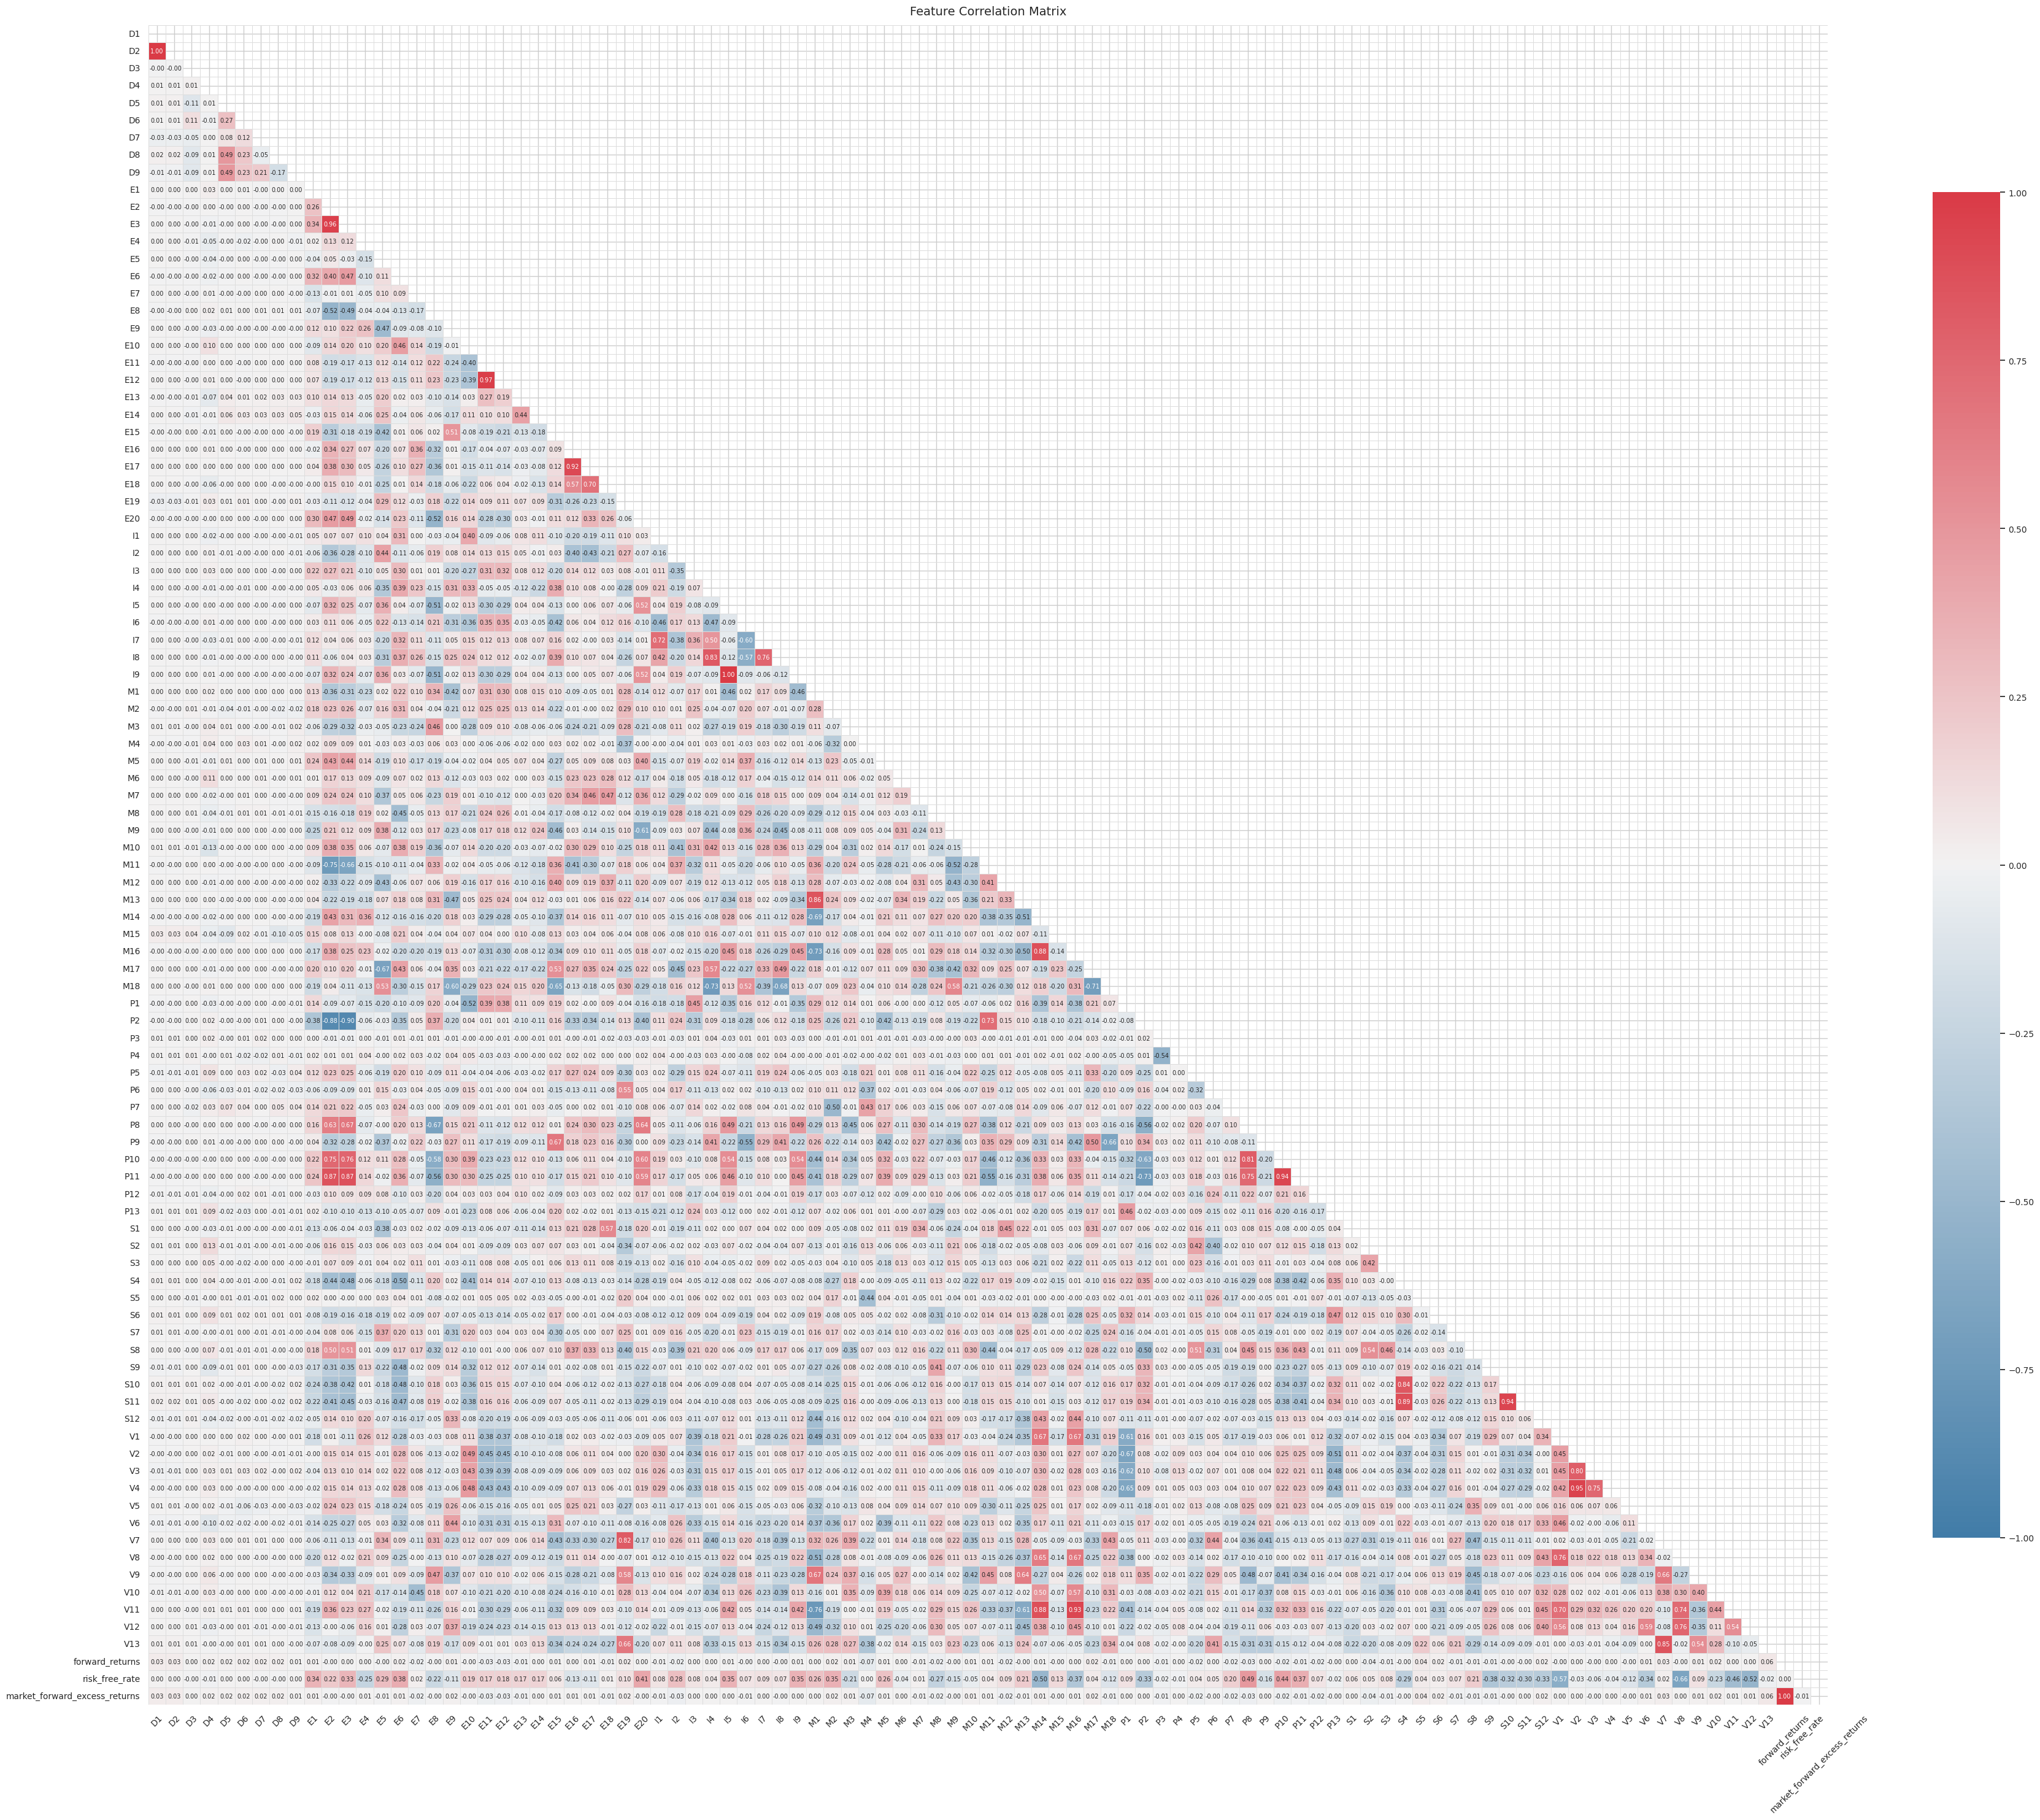

In [8]:
correlation(train_df)

# Other functions¶

In [9]:
def now_str() -> str:
    return time.strftime("%Y-%m-%d %H:%M:%S")

def timer(func):
    #Decorator to time a function and print elapsed time.
    def wrapper(*args, **kwargs):
        start = time.time()
        print(f"[{now_str()}] START {func.__name__}")
        result = func(*args, **kwargs)
        elapsed = time.time() - start
        print(f"[{now_str()}] DONE  {func.__name__} (elapsed {elapsed:.1f}s)")
        return result
    return wrapper

def safe_spearman(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    #Compute Spearman correlation
    corr, _ = spearmanr(y_true, y_pred)
    if np.isnan(corr):
        return -1.0
    return float(corr)

def time_series_cv_splits(X: pd.DataFrame, n_splits: int = 4):
    #Yield train/val indices for a TimeSeriesSplit.
    tscv = TimeSeriesSplit(n_splits=n_splits)
    return tscv.split(X)

# Model Define

In [10]:
# ModelTuner
class ModelTuner:    
    def __init__(self, seed: int = 42, n_splits: int = 4):
        self.seed = seed
        self.n_splits = n_splits

    @timer
    def tune_lightgbm(self, X: pd.DataFrame, y: pd.Series, n_trials: int = 30, n_jobs: int = 1) -> optuna.study.Study:
        """Tune LGBM with Optuna optimizing mean Spearman across time-series folds."""
        sampler = optuna.samplers.TPESampler(seed=self.seed)
        study = optuna.create_study(direction="maximize", sampler=sampler)

        def objective(trial):
            # Cross-validation of time series
            fold_scores = []
            tscv = TimeSeriesSplit(n_splits=self.n_splits)
            
            params = {
                "objective": "regression",                                                  # Task Type: Regression
                "metric": "rmse",                                                           # Evaluation Index: Root mean square error
                "n_estimators": trial.suggest_int("n_estimators", 400, 2600),               # The number of trees
                "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True), # learning rate
                "max_depth": trial.suggest_int("max_depth", 3, 12),                         # Maximum depth of the tree
                "num_leaves": trial.suggest_int("num_leaves", 16, 1000),                    # Number of leaf nodes
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),       # L2 Regularization
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),         # L1 Regularization
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),      # Feature sampling ratio
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),                    # Data sampling ratio
                "subsample_freq": 1,                                                        # Perform a sub-sampling every k iterations
                "random_state": self.seed,
                "verbosity": -1    # Silent mode, no training logs are output
            }

            for train_idx, val_idx in tscv.split(X):
                model = LGBMRegressor(**params)  # Create model
                model.fit(
                    X.iloc[train_idx], y.iloc[train_idx], # Training data
                    eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],  # Validation data
                    eval_metric="rmse",
                    callbacks=[early_stopping(stopping_rounds=100, verbose=False), log_evaluation(period=0)]  # Early Stop Strategy
                )
                preds = model.predict(X.iloc[val_idx])
                fold_scores.append(safe_spearman(y.iloc[val_idx].values, preds))
                # print(f"fold score: {fold_scores}")

            return float(np.mean(fold_scores))

        # Use Optuna for hyperparameter optimization
        # Display progress bars
        study.optimize(objective, n_trials=n_trials, n_jobs=n_jobs, show_progress_bar=True)
        return study

    # Final training utilities
    @timer
    def train_final_lgbm(self, X: pd.DataFrame, y: pd.Series, best_params: Dict[str,Any], model_path: str):
        """
        Train the final lgbm model with the best parameters
        
        inputs:
        - X: Features DataFrame (n_samples, n_features)
        - y: Target Series (n_samples,)
        - best_params: Optimal hyperparameter dictionary
        - model_path: Model saving path
        
        Output:
        - LGBMRegressor: The trained model
        """
        p = dict(best_params)
        p.setdefault("random_state", self.seed)
        p.setdefault("verbosity", -1)
        model = LGBMRegressor(**p)
        model.fit(X, y)
        joblib.dump(model, model_path)
        return model

# Plots features

def plot_feature_importance_lgbm(model: LGBMRegressor, feature_names: List[str], top_n: int = 20, figsize=(10,8), save_path: Optional[str]=None):
    """Plot top_n LGBM feature importances (gain)."""
    # try booster_.feature_importance to get 'gain' if available
    try:
        imp = model.booster_.feature_importance(importance_type="gain")
    except Exception:
        imp = model.feature_importances_
    imp = np.array(imp)
    indices = np.argsort(imp)[::-1][:top_n]
    names = np.array(feature_names)[indices]
    values = imp[indices]

    plt.figure(figsize=figsize)
    plt.barh(names, values)
    plt.gca().invert_yaxis()
    plt.xlabel("Importance (gain)")
    plt.title(f"LightGBM Top-{top_n} Feature Importances")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

## Base feature selection (using RandomForest)

In [11]:
def feature_selection(train_data,target_column='forward_returns', potential_features = None,
    num_trials=60, num_features_to_select=30, test_size=0.2, random_state=42, model_params=None):
    
    # set random seed
    random.seed(random_state)
    np.random.seed(random_state)
    
    X_full = train_data[potential_features]
    y_full = train_data[target_column]
   
    # Divide the data
    X_train, X_val, y_train, y_val = train_test_split(
        X_full, y_full, test_size=test_size, random_state=random_state, shuffle=False
    )
    
    print(f"Train data: {X_train.shape}")
    print(f"Validation data: {X_val.shape}")
    
    # Default model parameters
    if model_params is None:
        model_params = {'n_estimators': 50, 'random_state': random_state, 'max_depth': 8, 'n_jobs': -1}
    
    def evaluate_feature_set(features, X_train, X_val, y_train, y_val):
        """Evaluate the performance of a feature set"""
        # Use the random forest model
        model = RandomForestRegressor(**model_params)
        model.fit(X_train[features], y_train)
        y_pred = model.predict(X_val[features])
        mse = mean_squared_error(y_val, y_pred)
            
        return mse,model

    best_features = None
    best_mse = float('inf')
    best_model = None
    all_trials_results = []
    
    for i in range(num_trials):
        # Random selection of features
        current_features = random.sample(potential_features, num_features_to_select)
        
        # Evaluate this combination of features
        current_mse, current_model = evaluate_feature_set(current_features, X_train, X_val, y_train, y_val)
        print(f"set {i+1}: MSE = {current_mse:.8f}")
        
        # Update the best combination
        if current_mse < best_mse:
            best_mse = current_mse
            best_features = current_features
            best_model = current_model
            print(f"  ↳ The new best combination!")
    
    return best_features

In [12]:
train_clean = train_df.iloc[1006:].copy()
train_clean = train_clean.fillna(method='ffill')
train_clean = train_clean.fillna(0)
all_columns = train_clean.columns.tolist()
non_feature_cols = ['date_id', 'forward_returns', 'risk_free_rate', 'market_forward_excess_returns', 'E7', 'V10', 'S3', 'M1', 'M14', 'M13', 'M6', 'V9']
potential_features = [col for col in all_columns if col not in non_feature_cols]
TOP_FEATURES_FOR_FE = feature_selection(train_clean,potential_features = potential_features)
TOP_FEATURES_FOR_FE

Train data: (6412, 86)
Validation data: (1603, 86)
set 1: MSE = 0.00013052
  ↳ The new best combination!
set 2: MSE = 0.00012848
  ↳ The new best combination!
set 3: MSE = 0.00012945
set 4: MSE = 0.00012853
set 5: MSE = 0.00012980
set 6: MSE = 0.00012692
  ↳ The new best combination!
set 7: MSE = 0.00012763
set 8: MSE = 0.00013172
set 9: MSE = 0.00012817
set 10: MSE = 0.00012898
set 11: MSE = 0.00013158
set 12: MSE = 0.00013016
set 13: MSE = 0.00012937
set 14: MSE = 0.00013010
set 15: MSE = 0.00013065
set 16: MSE = 0.00013061
set 17: MSE = 0.00013562
set 18: MSE = 0.00012729
set 19: MSE = 0.00012892
set 20: MSE = 0.00013161
set 21: MSE = 0.00012761
set 22: MSE = 0.00013278
set 23: MSE = 0.00013095
set 24: MSE = 0.00013011
set 25: MSE = 0.00012627
  ↳ The new best combination!
set 26: MSE = 0.00012815
set 27: MSE = 0.00013026
set 28: MSE = 0.00012943
set 29: MSE = 0.00013503
set 30: MSE = 0.00012905
set 31: MSE = 0.00013057
set 32: MSE = 0.00012876
set 33: MSE = 0.00012996
set 34: MSE =

['E13',
 'I4',
 'P13',
 'V1',
 'P1',
 'S12',
 'E10',
 'M9',
 'M12',
 'M18',
 'I1',
 'M17',
 'E20',
 'E1',
 'S10',
 'E14',
 'V3',
 'S6',
 'E5',
 'M2',
 'S11',
 'E18',
 'I3',
 'D7',
 'S7',
 'E16',
 'E12',
 'E11',
 'M11',
 'P7']

# Config

In [13]:
TRAIN_PATH = '/kaggle/input/hull-tactical-market-prediction/train.csv'
LOCAL_GATEWAY_PATH = '/kaggle/input/hull-tactical-market-prediction/'

LAG_PERIODS = [1, 3, 5, 7, 14, 20]
ROLLING_WINDOWS = [3, 6, 10, 20, 60]

TARGET = 'market_forward_excess_returns'
# Remove the features with a missing rate greater than 50%
COLS_TO_DROP = ['forward_returns', 'risk_free_rate', 'excess_return', 'E7', 'V10', 'S3', 'M1', 'M14', 'M13', 'M6', 'V9']
TUNER_SEED = 2
N_TRIALS_LIGHTGBM = 10 
N_SPLITS = 4  

# Train Pipeline


--- Loading data ---

--- Creating features ---


[I 2025-12-09 02:27:35,842] A new study created in memory with name: no-name-40c9b509-404f-41aa-b592-fd686f120e03


X shape: (8015, 2276)  y shape: (8015,)

--- Tuning LightGBM ---
[2025-12-09 02:27:35] START tune_lightgbm


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-12-09 02:29:11,663] Trial 0 finished with value: 0.049144169664389885 and parameters: {'n_estimators': 1359, 'learning_rate': 0.0011268145953419496, 'max_depth': 8, 'num_leaves': 444, 'reg_lambda': 0.03588623449925766, 'reg_alpha': 0.01666857963613953, 'colsample_bytree': 0.6023243170189212, 'subsample': 0.8477083865402655}. Best is trial 0 with value: 0.049144169664389885.
[I 2025-12-09 02:30:40,156] Trial 1 finished with value: 0.0557485575301407 and parameters: {'n_estimators': 1059, 'learning_rate': 0.003417075308021128, 'max_depth': 9, 'num_leaves': 537, 'reg_lambda': 0.003146351080334255, 'reg_alpha': 0.07937981189740896, 'colsample_bytree': 0.5922199328234576, 'subsample': 0.9141340591266693}. Best is trial 1 with value: 0.0557485575301407.
[I 2025-12-09 02:31:37,051] Trial 2 finished with value: 0.04060336774960015 and parameters: {'n_estimators': 2279, 'learning_rate': 0.0097380875505427, 'max_depth': 11, 'num_leaves': 94, 'reg_lambda': 0.07394181933573325, 'reg_alpha'

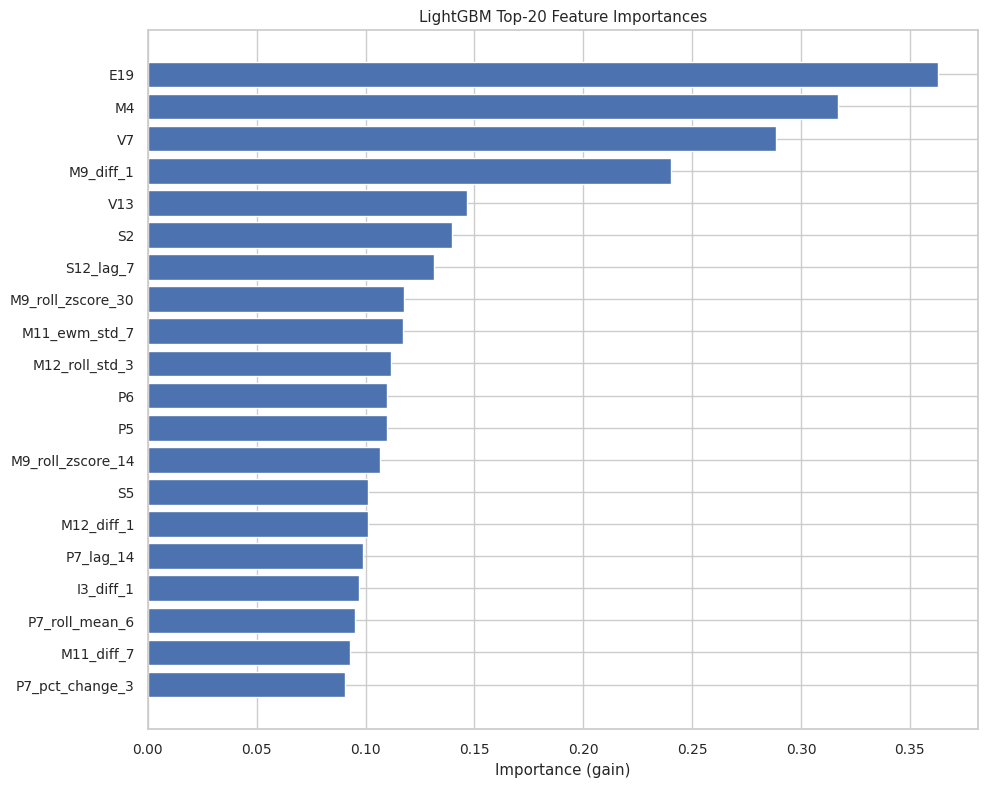

5281

In [14]:
# Load + preprocess
print("\n--- Loading data ---")
df = pd.read_csv(TRAIN_PATH)
if 'date_id' not in df.columns:
    df['date_id'] = df.index

# 删除第 2 行到第 1007 行
df = df.iloc[1006:].reset_index(drop=True)
df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns], inplace=True)

print("\n--- Creating features ---")
df_feat = create_features(df)
df_feat.dropna(subset=[TARGET], inplace=True)

FEATURES = [c for c in df_feat.columns if c not in [TARGET, 'date_id']]
X = df_feat[FEATURES]
y = df_feat[TARGET]

print(f"X shape: {X.shape}  y shape: {y.shape}")

tuner = ModelTuner(seed=TUNER_SEED, n_splits=N_SPLITS)

# Tune LightGBM
print("\n--- Tuning LightGBM ---")
study_lgb = tuner.tune_lightgbm(X, y, n_trials=N_TRIALS_LIGHTGBM, n_jobs=1)
print("LGB study best value (mean Spearman):", study_lgb.best_value)
print("LGB best params (trimmed):", {k: study_lgb.best_params[k] for k in study_lgb.best_params})

# Train final LightGBM
print("\n--- Training final LightGBM ---")
final_lgb = tuner.train_final_lgbm(X, y, study_lgb.best_params, "final_lgbm.joblib")
print("Saved final_lgbm.joblib")

# Plot top features for LGBM
print("\n--- LGBM Feature Importance (top 20) ---")
plot_feature_importance_lgbm(final_lgb, FEATURES, top_n=20)

# Save the features used for inference
joblib.dump(FEATURES, "features_lgbm.joblib")

# Clean up
gc.collect()